# ORACLE, MedQA USMLE EDA
## Clinical QA Domain

**Dataset:** MedQA USMLE, Jin et al. (2021), Applied Sciences  
**Records:** 11,451 (train: 10,178 | test: 1,273)  
**Labels:** Correct option (A/B/C/D)  
**Domain:** Clinical QA, English  

**Key facts:**
- USMLE board exam questions, hardest biomedical QA benchmark
- Step 1 (55.3%) and Step 2&3 (44.7%)
- Step 2&3 questions much longer (856 vs 617 chars)
- Near-balanced answer distribution
- Mean 35.8 MetaMap clinical entities per question
- Mean question length 724 chars vs MedMCQA 79 chars

**ORACLE use:** Clinical retrieval quality ceiling, if ORACLE maintains USMLE performance while improving accessibility, that validates the architecture.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from medqa_loader import load_medqa_all

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

OPTION_COLORS = ['#5cb85c','steelblue','coral','#f0ad4e']
STEP_COLORS = {'step1':'steelblue','step2&3':'coral'}
print('Imports complete')

Imports complete


In [2]:
result = load_medqa_all()
df = result['train']['data'].copy()
df['label'] = result['train']['labels'].values
df['q_len'] = df['question'].astype(str).str.len()
df['n_phrases'] = df['metamap_phrases'].apply(lambda x: len(x) if hasattr(x,'__len__') else 0)

def opt_len(opts, key):
    try: return len(str(opts.get(key,'')))
    except: return 0

for opt in ['A','B','C','D']:
    df[f'opt_{opt}_len'] = df['options'].apply(lambda x: opt_len(x, opt))

print(f'Shape: {df.shape}')
print(f'Train records: {len(df):,}')

Loading MedQA USMLE, all splits...


  train: 10,178 records
  test: 1,273 records

MedQA USMLE loaded: 11,451 total records
  Note: 4-options version, original paper reported 12,723
Shape: (10178, 11)
Train records: 10,178


## 1. Split Sizes Overview

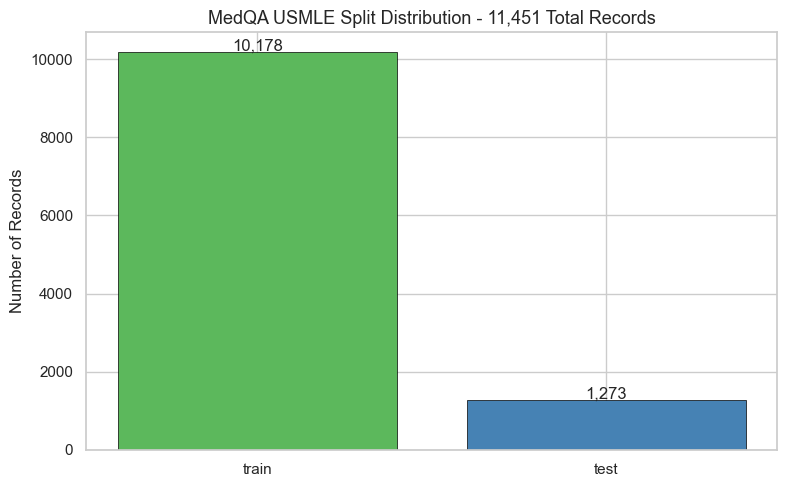

In [3]:
splits = ['train','test']
sizes = [result[s]['metadata']['n_samples'] for s in splits]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(splits, sizes, color=['#5cb85c','steelblue'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}', ha='center', fontsize=12)
ax.set_title('MedQA USMLE Split Distribution - 11,451 Total Records', fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/medqa_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Answer Distribution, Near-Balanced

Slight B bias (26.1%). Well-designed exam with balanced answer distribution.

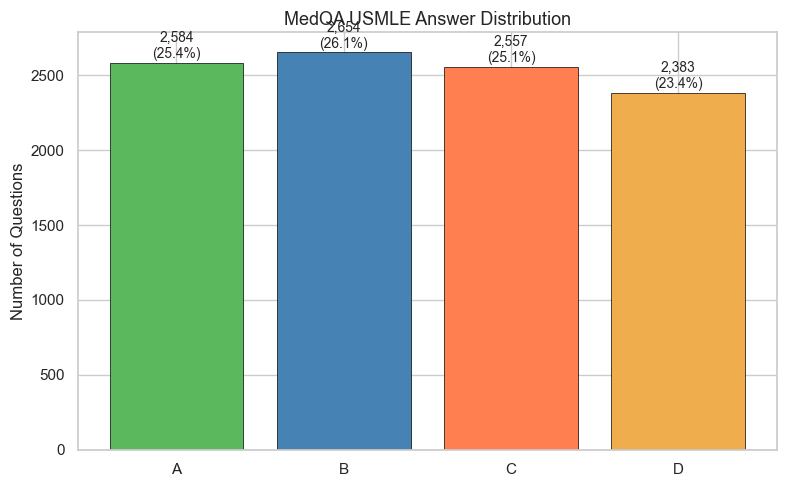

In [4]:
label_counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(['A','B','C','D'], [label_counts[o] for o in 'ABCD'],
              color=OPTION_COLORS, edgecolor='black', linewidth=0.5)
for bar, opt in zip(bars, 'ABCD'):
    val = label_counts[opt]
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
ax.set_title('MedQA USMLE Answer Distribution', fontsize=13)
ax.set_ylabel('Number of Questions')
plt.tight_layout()
plt.savefig('../figures/eda/medqa_answer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. USMLE Step Distribution

Step 1 (55.3%) vs Step 2&3 (44.7%). Step 2&3 tests clinical application.

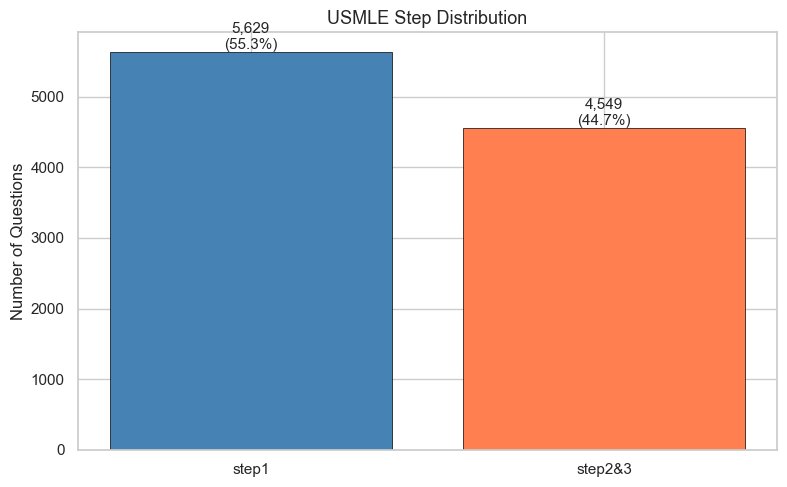

In [5]:
step_counts = df['meta_info'].value_counts()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(step_counts.index, step_counts.values,
              color=[STEP_COLORS.get(s,'gray') for s in step_counts.index],
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, step_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('USMLE Step Distribution', fontsize=13)
ax.set_ylabel('Number of Questions')
plt.tight_layout()
plt.savefig('../figures/eda/medqa_step_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Question Length Distribution

Mean 724 chars, full clinical scenarios. Much longer than MedMCQA (mean 79 chars).

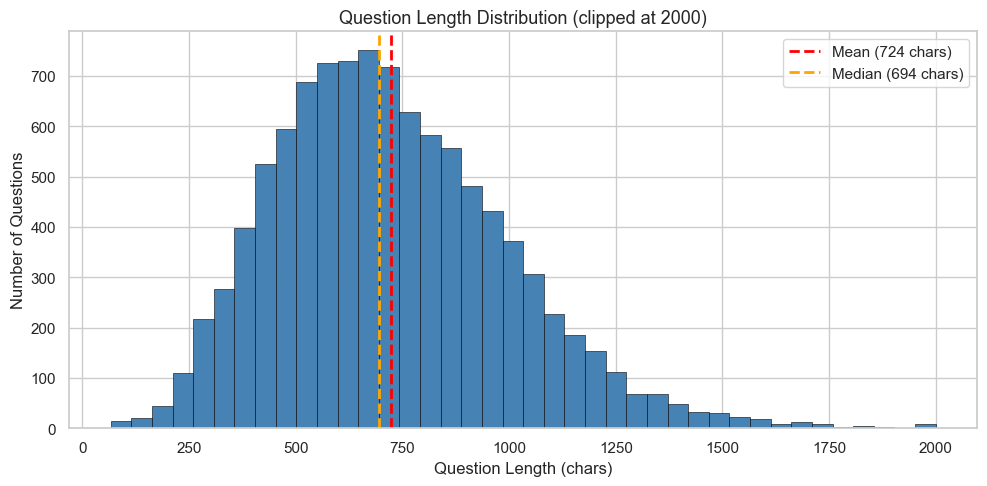

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df['q_len'].clip(upper=2000), bins=40, color='steelblue',
        edgecolor='black', linewidth=0.4)
ax.axvline(x=df['q_len'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean ({df["q_len"].mean():.0f} chars)')
ax.axvline(x=df['q_len'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median ({df["q_len"].median():.0f} chars)')
ax.set_title('Question Length Distribution (clipped at 2000)', fontsize=13)
ax.set_xlabel('Question Length (chars)')
ax.set_ylabel('Number of Questions')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medqa_question_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Question Length by USMLE Step

Step 2&3 questions (mean 856) are 38% longer than Step 1 (mean 617), more complex clinical scenarios.

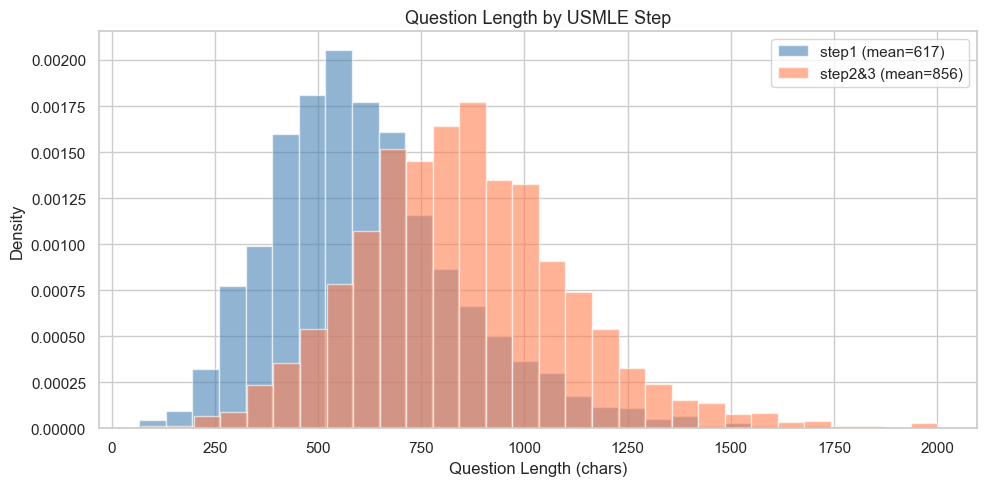

Step 2&3 (856) is 38% longer than Step 1 (617), critical for RAG chunking


In [7]:
fig, ax = plt.subplots(figsize=(10,5))
for step, color in STEP_COLORS.items():
    subset = df[df['meta_info']==step]['q_len'].clip(upper=2000)
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=f'{step} (mean={df[df["meta_info"]==step]["q_len"].mean():.0f})', density=True)
ax.set_title('Question Length by USMLE Step', fontsize=13)
ax.set_xlabel('Question Length (chars)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medqa_length_by_step.png', dpi=150, bbox_inches='tight')
plt.show()
print('Step 2&3 (856) is 38% longer than Step 1 (617), critical for RAG chunking')

## 6. Question Length by Answer Option

Near-identical length across options, no answer-length bias.

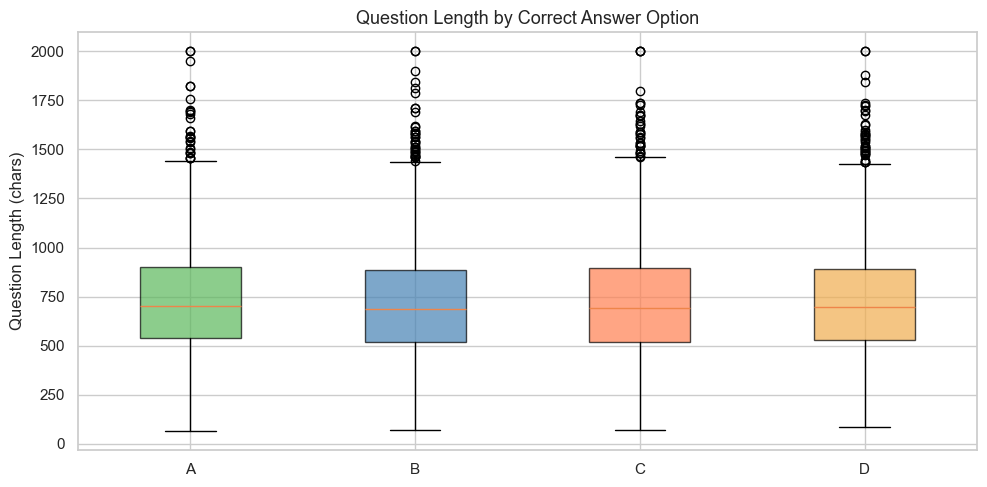

Near-identical length across options, no answer-length bias


In [8]:
fig, ax = plt.subplots(figsize=(10,5))
data = [df[df['label']==opt]['q_len'].clip(upper=2000) for opt in 'ABCD']
bp = ax.boxplot(data, labels=list('ABCD'), patch_artist=True)
for patch, color in zip(bp['boxes'], OPTION_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Question Length by Correct Answer Option', fontsize=13)
ax.set_ylabel('Question Length (chars)')
plt.tight_layout()
plt.savefig('../figures/eda/medqa_length_by_answer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Near-identical length across options, no answer-length bias')

## 7. Answer Option Length Comparison

All options nearly identical length (mean 27 chars), balanced MCQ design.

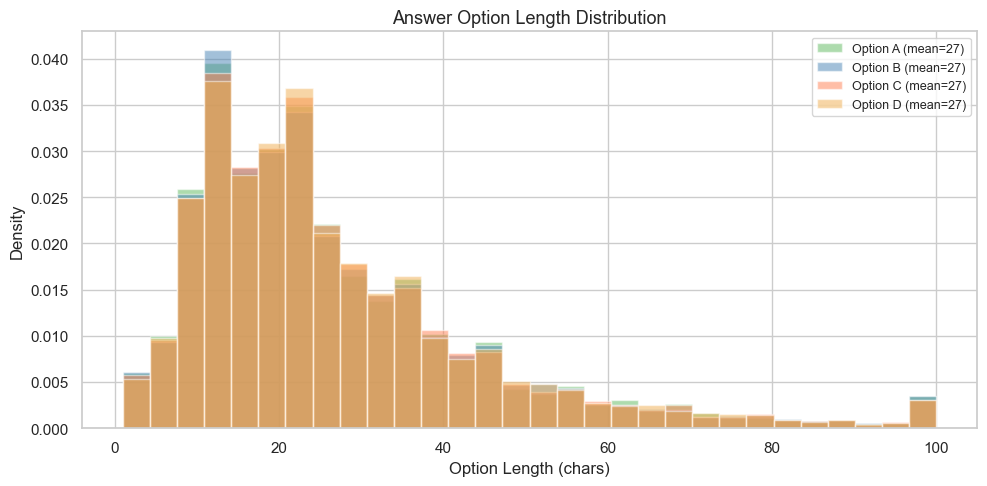

In [9]:
fig, ax = plt.subplots(figsize=(10,5))
opt_cols = ['opt_A_len','opt_B_len','opt_C_len','opt_D_len']
for col, label, color in zip(opt_cols, 'ABCD', OPTION_COLORS):
    ax.hist(df[col].clip(upper=100), bins=30, alpha=0.5, density=True,
            color=color, label=f'Option {label} (mean={df[col].mean():.0f})')
ax.set_title('Answer Option Length Distribution', fontsize=13)
ax.set_xlabel('Option Length (chars)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/medqa_option_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. MetaMap Phrases Distribution

Mean 35.8 clinical entities per question, rich semantic annotation for RAG retrieval.

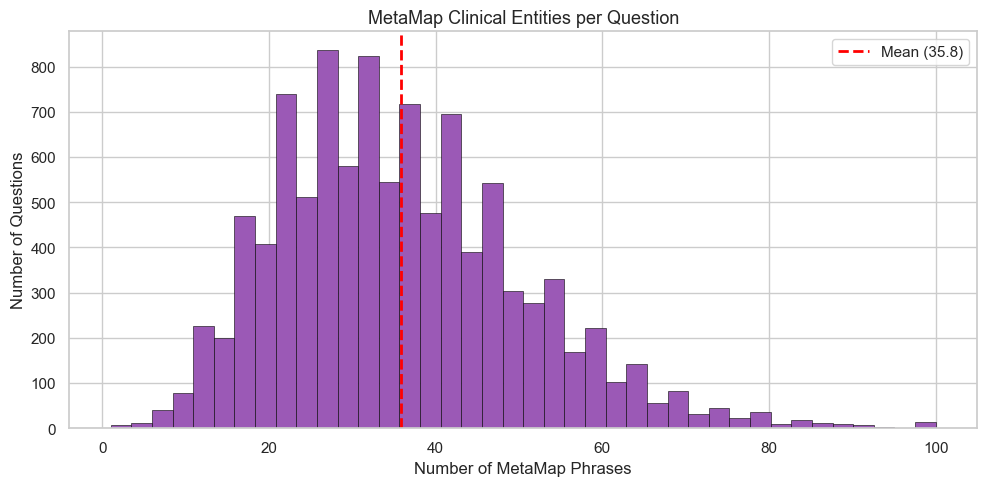

Mean 35.8 entities, rich clinical annotation for ORACLE retrieval


In [10]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df['n_phrases'].clip(upper=100), bins=40, color='#9b59b6',
        edgecolor='black', linewidth=0.4)
ax.axvline(x=df['n_phrases'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean ({df["n_phrases"].mean():.1f})')
ax.set_title('MetaMap Clinical Entities per Question', fontsize=13)
ax.set_xlabel('Number of MetaMap Phrases')
ax.set_ylabel('Number of Questions')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medqa_metamap_phrases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Mean 35.8 entities, rich clinical annotation for ORACLE retrieval')

## 9. Answer Bias by USMLE Step

Bias nearly identical across steps, answer distribution is structural, not content-driven.

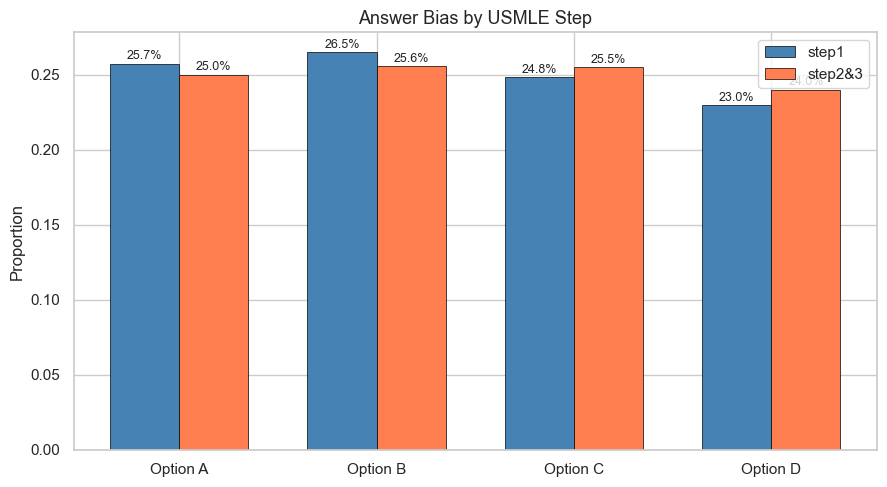

In [11]:
steps = ['step1','step2&3']
opts = list('ABCD')
bias_data = {}
for step in steps:
    subset = df[df['meta_info']==step]
    bias_data[step] = [subset[subset['label']==opt].shape[0]/len(subset) for opt in opts]

x = np.arange(len(opts)); width = 0.35
fig, ax = plt.subplots(figsize=(9,5))
for i, (step, rates) in enumerate(bias_data.items()):
    bars = ax.bar(x+i*width, rates, width, label=step,
                  color=list(STEP_COLORS.values())[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.1%}', ha='center', fontsize=9)
ax.set_xticks(x+width/2); ax.set_xticklabels([f'Option {o}' for o in opts])
ax.set_title('Answer Bias by USMLE Step', fontsize=13)
ax.set_ylabel('Proportion'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medqa_answer_bias_by_step.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. MedQA vs MedMCQA, Question Length Comparison

MedQA (724) is 9× longer than MedMCQA (79). Critical difference for ORACLE chunking strategy.

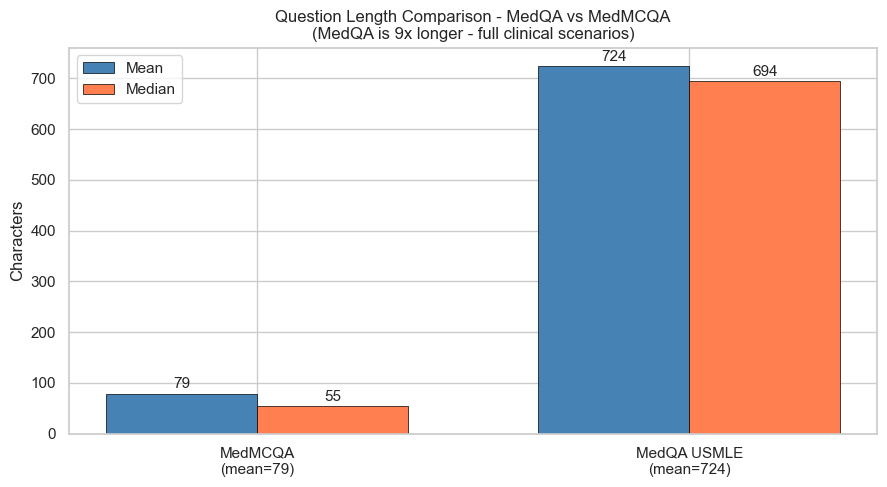

MedQA 9x longer than MedMCQA, different chunking strategy required in ORACLE Stage 1


In [12]:
datasets = ['MedMCQA\n(mean=79)', 'MedQA USMLE\n(mean=724)']
means = [79, 724]
medians = [55, 694]

x = np.arange(len(datasets)); width = 0.35
fig, ax = plt.subplots(figsize=(9,5))
bars1 = ax.bar(x-width/2, means, width, label='Mean', color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x+width/2, medians, width, label='Median', color='coral', edgecolor='black', linewidth=0.5)
for bar, val in zip(list(bars1)+list(bars2), means+medians):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{val}', ha='center', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(datasets)
ax.set_title('Question Length Comparison - MedQA vs MedMCQA\n(MedQA is 9x longer - full clinical scenarios)', fontsize=12)
ax.set_ylabel('Characters'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/medqa_vs_medmcqa_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('MedQA 9x longer than MedMCQA, different chunking strategy required in ORACLE Stage 1')

## 11. Key Observations

**Scale:** 11,451 USMLE board exam questions across Step 1 and Step 2&3.

**Question complexity:** Mean 724 chars, 9× longer than MedMCQA (79 chars). Full clinical vignettes with patient presentation, vitals, exam findings.

**Step 2&3 longer:** Step 2&3 questions (mean 856 chars) are 38% longer than Step 1 (617 chars), complex clinical reasoning scenarios.

**Near-balanced answers:** Slight B bias (26.1%) consistent across both steps, structural design pattern, not content-driven.

**MetaMap coverage:** Mean 35.8 clinical entities per question, rich semantic annotation available for ORACLE retrieval enhancement.

**ORACLE implication:** MedQA's question length requires different chunking strategy than MedMCQA. Used as retrieval quality ceiling, ORACLE must maintain USMLE performance while improving accessibility.